# TP 2 - CNN for cells classification

In [2]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import functools as ft
from sklearn.model_selection import train_test_split
from PIL import Image
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score
from torch.utils.data.sampler import WeightedRandomSampler
from sklearn.metrics import confusion_matrix, classification_report
from pylab import rcParams
import torch.optim as optim
#from google.colab import drive
import torchvision
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch
from torchvision.models import resnet50, ResNet50_Weights


In [3]:
def plot_confusion(prediction, target):
    '''
    plot correlation's matrix to explore dependency between features
    '''
    # init figure size
    list_labels_cat = ['ARTEFACTS',
          'BASOPHILES',
          'BLASTES',
          'EOSINOPHILES',
          'ERYTHROBLASTES',
          'LYMPHOCYTES',
          'METAMYELOCYTES',
          'MONOCYTES',
          'MYELOCYTES',
          'NEUTROPHILES',
          'PROMYELOCYTES']
    targ_valids_cat = [list_labels_cat[i] for i in target]
    preds_valids_cat = [list_labels_cat[i] for i in prediction]
    rcParams['figure.figsize'] = 7, 7
    df = pd.DataFrame(confusion_matrix(targ_valids_cat, preds_valids_cat, labels = list_labels_cat, normalize='true'), index = list_labels_cat, columns= list_labels_cat)
    # df = pd.DataFrame(confusion_matrix(targ_valids_cat, preds_valids_cat, labels = list_labels_cat, normalize = 'true'))

    fig = plt.figure()
    sns.heatmap(df, annot=True, fmt=".2f")
    plt.show()
    fig.savefig('corr.png')



# Import features

In [ ]:
drive.mount('/content/drive')
!ls

Mounted at /content/drive
drive  sample_data


# Understanding an image with Python

Our images are 250x250x3 numpy matrices.

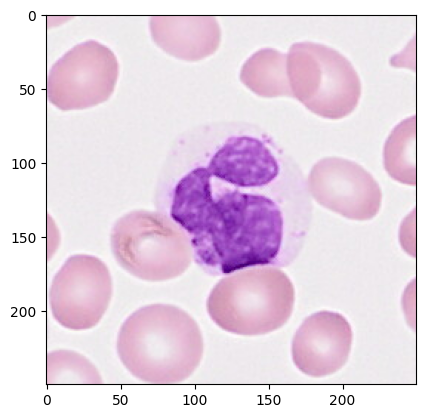

In [4]:
image = Image.open('data/allImages_247_282/image1.png').convert('RGB')
image = np.array(image)
plt.imshow(image)

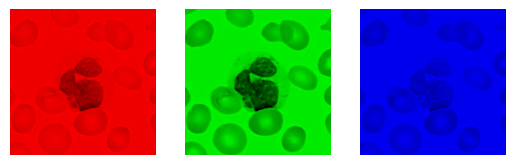

In [5]:
figure, plots = plt.subplots(ncols=3, nrows=1)
for i, subplot in zip(range(3), plots):
    temp = np.zeros(image.shape, dtype='uint8')
    temp[:,:,i] = image[:,:,i]
    subplot.imshow(temp)
    subplot.set_axis_off()
plt.show()

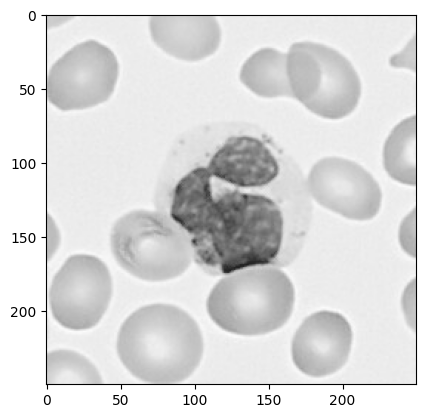

In [6]:
image_grey = Image.open('data/allImages_247_282/image1.png').convert('LA')
plt.imshow(image_grey)

# Image transformations

1. Using transforms package, apply the following transformations to *image*:




*   Transform from image to tensor
*   Normalize image so that all pixel values are between 0 and 1, with 0.5 mean and 0.5 standard deviation
*   Crop image
*   Put a random horizontal flip
*   Jitter the colour of the image
*   Add a gaussian blur


Remark: you can use `transforms.Compose` to use several transformations at the same time.


Examples of expected results:

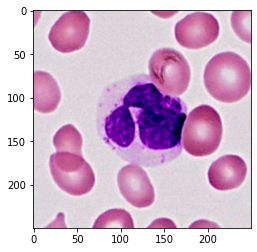


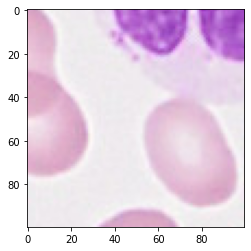

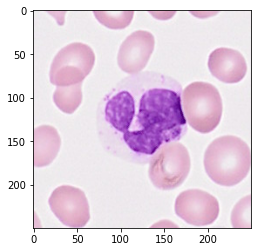

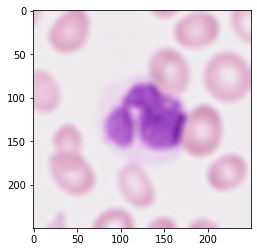



# Add labels

In [7]:
labels = pd.read_csv('labels.csv')

In [8]:
labels['label'].value_counts()

label
ERYTHROBLASTES    1324
NEUTROPHILES       760
LYMPHOCYTES        357
ARTEFACTS          237
MONOCYTES          162
BLASTES             93
MYELOCYTES          78
BASOPHILES          69
METAMYELOCYTES      46
EOSINOPHILES         7
PROMYELOCYTES        7
Name: count, dtype: int64

## Labels encoding



2. a. Use the `LabelEncoder() `to convert categorical labels to numbers.

   b. Use `train_test_split` to split the dataset into 2 subdataframes `train` and `test` (test_size = 0.2, random_state = 42)


# Create dataloader

You will now have to create 2 dataloaders, `dataloader_train` and `dataloader_test` that will generate batches of images, from the train and the test dataframes.

To create a dataloader in Pytorch, you need first to create a `Dataset`.



*   The `Dataset` is a class.
*   It takes the labels dataframe as an input.
*   It has a `__getitem__` method. Input argument is an index `idx`, and it fetches the corresponding label and image.

Remark: images are in the folder **allImages_247_282** and are called image*cytoID*.png, with *cytoID* the number of their *cytoID*.






Help:
To create the class `MyDataset` you can use the stackoverflow below:
https://stackoverflow.com/questions/61391919/loading-image-data-from-pandas-to-pytorch


3. Create `dataloader_train` and `dataloader_test`, with `shuffle=True `and `batch_size = 8`.



**Bonus**: Modify `MyDataset` to add the possibility of applying a transform to the image.


In [9]:
label_encoder = LabelEncoder()
labels['label_encoded'] = label_encoder.fit_transform(labels['label'])

train, test = train_test_split(
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels['label_encoded']
)

train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

transform = transforms.ToTensor()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MyDataset(torch.utils.data.Dataset):
    def __init__(self, labels_df, transform=None):
        self.labels_df = labels_df
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        image = Image.open(f"data/allImages_247_282/image{row['cytoID']}.png").convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        label = int(row['label_encoded'])
        return image, label

train_dataset = MyDataset(train, transform=transform)
test_dataset = MyDataset(test, transform=transform)

dataloader_train = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
dataloader_test = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=True)

classes = label_encoder.classes_


In [10]:
batch = next(iter(dataloader_train))


## Visualization of a batch

4. Create one batch by using `next` and `iter` functions on your dataloader, and run the below cell to visualize it.

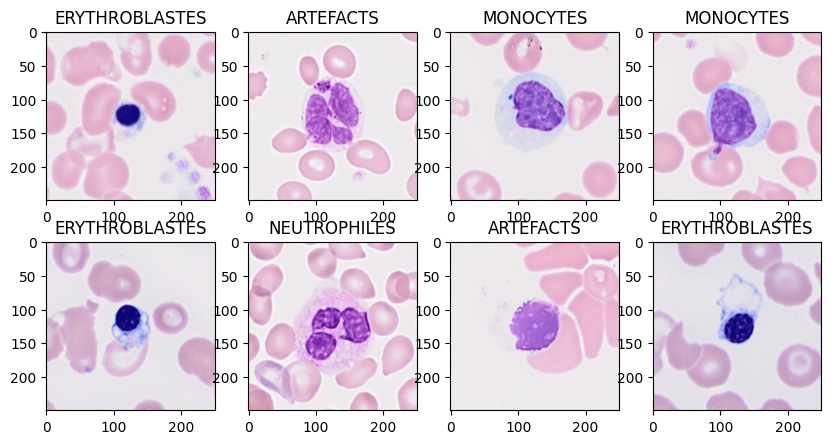

In [11]:
fig, axes = plt.subplots(2,4, figsize = ((10,5)))
for i, ax in enumerate(axes.flat):
    ax.imshow(batch[0][i].permute(2,1,0))
    ax.set_title(classes[batch[1][i].item()])

# Create a model

5. Create a model from scratch, composed of
* an encoder part with convolutional layers with relu activation, and pooling layers.
* a classifier part with fully connected layers.

You are free to decide of the architecture of your model.

Warning: the last layer must be composed of as many nodes as there are classes.

Don't forget to enable the access to GPU in Edit / Notebook Settings


In [12]:
class Net(nn.Module):
    ''' Models a simple Convolutional Neural Network'''
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, len(classes))
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return x


In [13]:
net = Net()
net = net.to(device)


## Define loss and optimizer

6. Create `loss` and `optimizer` variables.

`Loss` will be cross entropy loss and `optimizer` will be stochastic gradient descent.

In [14]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)


# Training the model

7. Create a function  `train_model(model, epochs, loss, optimizer, dataloader_train, dataloader_test) ` that would train your model on a certain number of epochs `epochs`, using `loss` and `optimizer`. For each epoch, it will print the train_loss and the val_loss

Warning: you will have to put model and batches from dataloader on the gpu if you want it to run at a decent speed.



8. Use `train_model` to train the model you just created (you can run it for 3 epochs). The training will be done with `dataloader_train`.


In [15]:
from tqdm import tqdm

def train_model(model, epochs, criterion, optimizer, dataloader_train, dataloader_test):
    device = next(model.parameters()).device

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for input_batch, label_batch in tqdm(dataloader_train):
            input_batch = input_batch.to(device)
            label_batch = label_batch.to(device)

            optimizer.zero_grad()
            outputs = model(input_batch)
            loss = criterion(outputs, label_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for input_batch, label_batch in dataloader_test:
                input_batch = input_batch.to(device)
                label_batch = label_batch.to(device)

                outputs = model(input_batch)
                loss = criterion(outputs, label_batch)
                val_loss += loss.item()

        train_loss /= len(dataloader_train)
        val_loss /= len(dataloader_test)
        print(f"Epoch {epoch + 1}/{epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")


In [16]:
train_model(net, 3, loss, optimizer, dataloader_train, dataloader_test)


100%|██████████| 314/314 [00:03<00:00, 91.61it/s]


Epoch 1/3 - train_loss: 1.8404 - val_loss: 1.6922


100%|██████████| 314/314 [00:03<00:00, 97.12it/s] 


Epoch 2/3 - train_loss: 1.6881 - val_loss: 1.6754


100%|██████████| 314/314 [00:03<00:00, 96.29it/s]


Epoch 3/3 - train_loss: 1.6874 - val_loss: 1.6807




# Visualise results

In [17]:
def find_accuracy(model, dataloader_test):
    correct = 0
    total = 0
    label_test = []
    predicted_test = []
    device = next(model.parameters()).device

    model.eval()
    with torch.no_grad():
        for images, labels in dataloader_test:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            label_test += labels.cpu().tolist()
            predicted_test += predicted.cpu().tolist()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the test images: %d %%' % (100 * correct / total))
    return predicted_test, label_test, correct / total


9. a. Find the accuracy of the model on the testing set with the function `find_accuracy`.

  b. Plot the confusion matrix and the classification report of your model on the testing set.

  c. What do you observe ?


Example of expected result:


  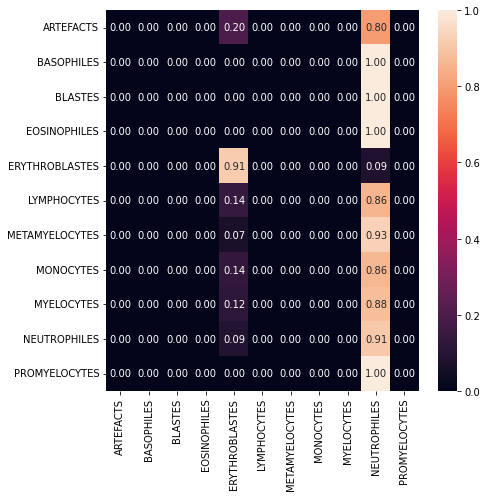

Accuracy of the network on the test images: 42 %


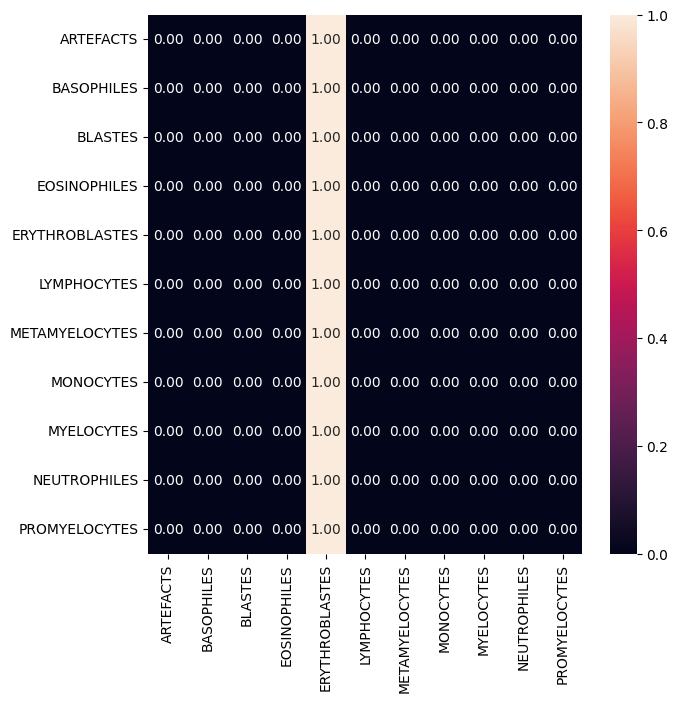

                precision    recall  f1-score   support

     ARTEFACTS       0.00      0.00      0.00        47
    BASOPHILES       0.00      0.00      0.00        14
       BLASTES       0.00      0.00      0.00        19
  EOSINOPHILES       0.00      0.00      0.00         1
ERYTHROBLASTES       0.42      1.00      0.59       265
   LYMPHOCYTES       0.00      0.00      0.00        71
METAMYELOCYTES       0.00      0.00      0.00         9
     MONOCYTES       0.00      0.00      0.00        33
    MYELOCYTES       0.00      0.00      0.00        16
  NEUTROPHILES       0.00      0.00      0.00       152
 PROMYELOCYTES       0.00      0.00      0.00         1

      accuracy                           0.42       628
     macro avg       0.04      0.09      0.05       628
  weighted avg       0.18      0.42      0.25       628



In [18]:
predicted_test, label_test, accuracy = find_accuracy(net, dataloader_test)
plot_confusion(predicted_test, label_test)
print(classification_report(
    label_test,
    predicted_test,
    labels=list(range(len(classes))),
    target_names=classes,
    zero_division=0
))


The test accuracy looks acceptable at first glance, but the detailed metrics show that the model has **mostly learned the majority classes** and struggles to generalize to the minority ones.

The confusion matrix and the classification report indicate that many rare classes are either never predicted or strongly confused with biologically similar classes. In practice, the CNN trained from scratch is still **too biased by class imbalance**: the global accuracy is inflated by the frequent classes, while per-class recall remains very uneven.

So the main conclusion is that accuracy alone is misleading here. The model captures part of the problem, but it is not yet reliable on the full 11-class task.

# Using a pretrained model

10. Now we will use a model that has been pretrained on ImageNet dataset. Create a new model by downloading `resnet50` from torch library, with using the option `pretrained = True`.

In [19]:
weights = ResNet50_Weights.DEFAULT
resnet_transform = weights.transforms()

train_dataset_resnet = MyDataset(train, transform=resnet_transform)
test_dataset_resnet = MyDataset(test, transform=resnet_transform)

dataloader_train_resnet = torch.utils.data.DataLoader(train_dataset_resnet, batch_size=8, shuffle=True)
dataloader_test_resnet = torch.utils.data.DataLoader(test_dataset_resnet, batch_size=8, shuffle=True)

resnet = resnet50(weights=weights)
resnet.fc = nn.Linear(resnet.fc.in_features, len(classes))
resnet = resnet.to(device)

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet.parameters(), lr=0.001, momentum=0.9)


11. Repeat 8 and 9 with your new model. What can you now tell about the pretrained model?





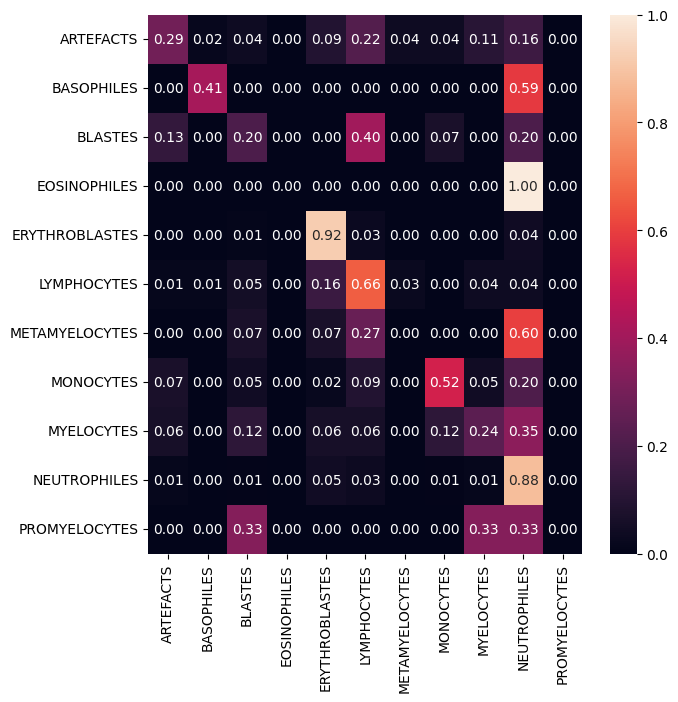

100%|██████████| 314/314 [00:09<00:00, 32.72it/s]


Epoch 1/3 - train_loss: 1.1624 - val_loss: 0.8418


100%|██████████| 314/314 [00:09<00:00, 31.67it/s]


Epoch 2/3 - train_loss: 0.7768 - val_loss: 0.7663


100%|██████████| 314/314 [00:09<00:00, 31.96it/s]


Epoch 3/3 - train_loss: 0.6397 - val_loss: 0.7169
Accuracy of the network on the test images: 76 %


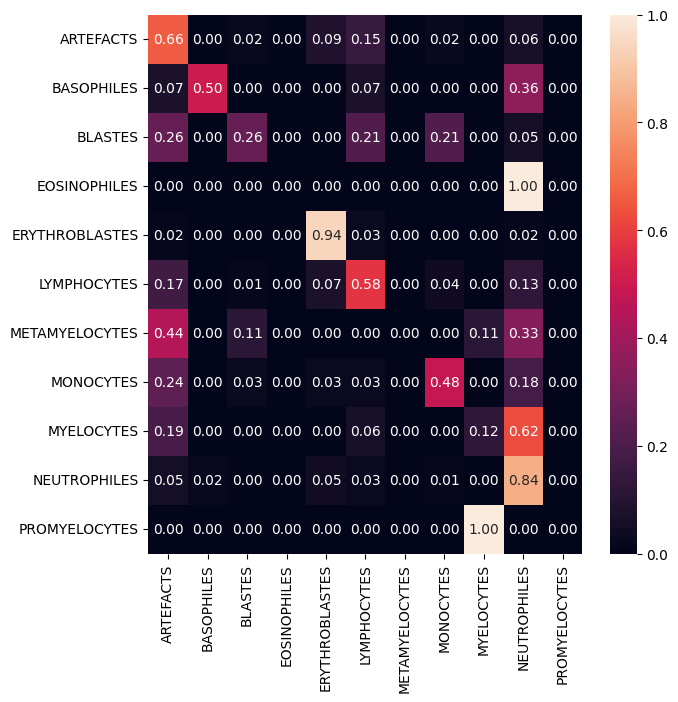

                precision    recall  f1-score   support

     ARTEFACTS       0.41      0.66      0.50        47
    BASOPHILES       0.70      0.50      0.58        14
       BLASTES       0.56      0.26      0.36        19
  EOSINOPHILES       0.00      0.00      0.00         1
ERYTHROBLASTES       0.94      0.94      0.94       265
   LYMPHOCYTES       0.62      0.58      0.60        71
METAMYELOCYTES       0.00      0.00      0.00         9
     MONOCYTES       0.62      0.48      0.54        33
    MYELOCYTES       0.50      0.12      0.20        16
  NEUTROPHILES       0.75      0.84      0.80       152
 PROMYELOCYTES       0.00      0.00      0.00         1

      accuracy                           0.76       628
     macro avg       0.46      0.40      0.41       628
  weighted avg       0.76      0.76      0.75       628



In [20]:
train_model(resnet, 3, loss, optimizer, dataloader_train_resnet, dataloader_test_resnet)
predicted_test, label_test, accuracy = find_accuracy(resnet, dataloader_test_resnet)
plot_confusion(predicted_test, label_test)
print(classification_report(
    label_test,
    predicted_test,
    labels=list(range(len(classes))),
    target_names=classes,
    zero_division=0
))


The pretrained ResNet clearly performs better than the small CNN trained from scratch. It converges faster, the confusion matrix is more structured, and the classification report shows a much better separation of the common classes.

This confirms the benefit of transfer learning: the pretrained filters already capture useful visual patterns, so the network needs less data to learn relevant cell features. However, the rarest classes still remain difficult, with lower recall and persistent confusions. So the pretrained model is **globally much more robust**, but class imbalance is still the main factor limiting the final performance.

# Dealing with unbalanced classes

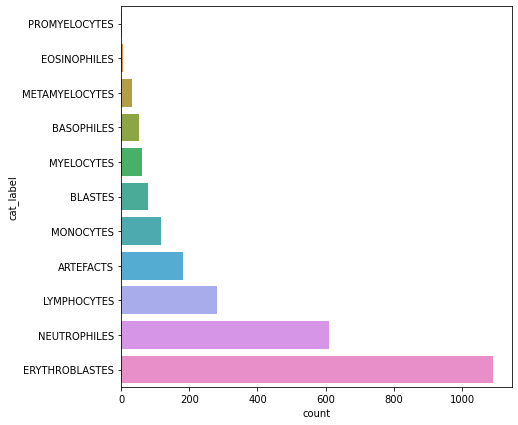

12. Even if results are getting better, underrepresented classes are still hard to classify. Create a new dataloader that would use a `WeightedRandomSampler` to make classes more balanced in every batch, and train again your model.

Remark: the training will be slower on the overrepresented classes than before, you can use a larger epochs number (such as 10 or more).

What results do you observe?

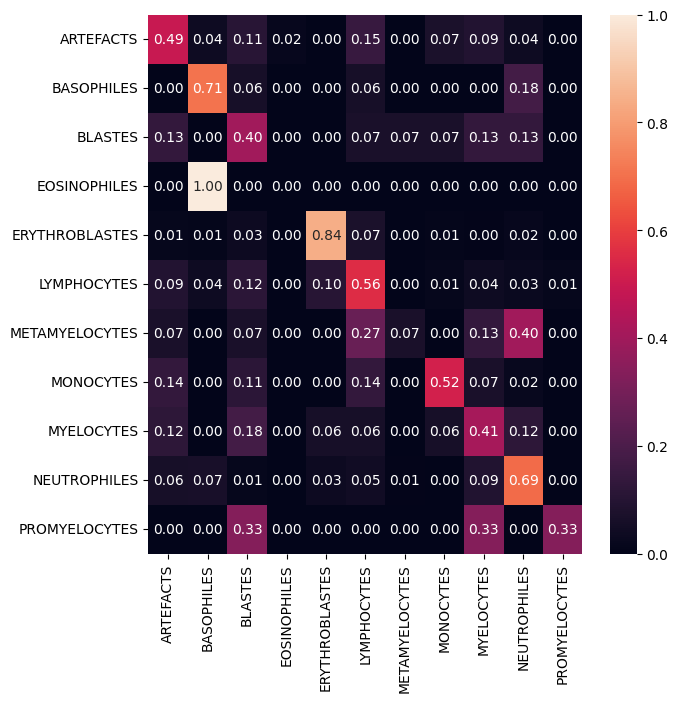

100%|██████████| 314/314 [00:09<00:00, 31.94it/s]


Epoch 1/10 - train_loss: 1.6986 - val_loss: 0.9984


100%|██████████| 314/314 [00:09<00:00, 31.66it/s]


Epoch 2/10 - train_loss: 0.7059 - val_loss: 0.8745


100%|██████████| 314/314 [00:11<00:00, 28.40it/s]


...

Epoch 8/10 - train_loss: 0.0885 - val_loss: 1.1081


100%|██████████| 314/314 [00:10<00:00, 31.36it/s]


Epoch 9/10 - train_loss: 0.0868 - val_loss: 1.0065


100%|██████████| 314/314 [00:09<00:00, 31.59it/s]


Epoch 10/10 - train_loss: 0.0642 - val_loss: 1.0275
Accuracy of the network on the test images: 77 %


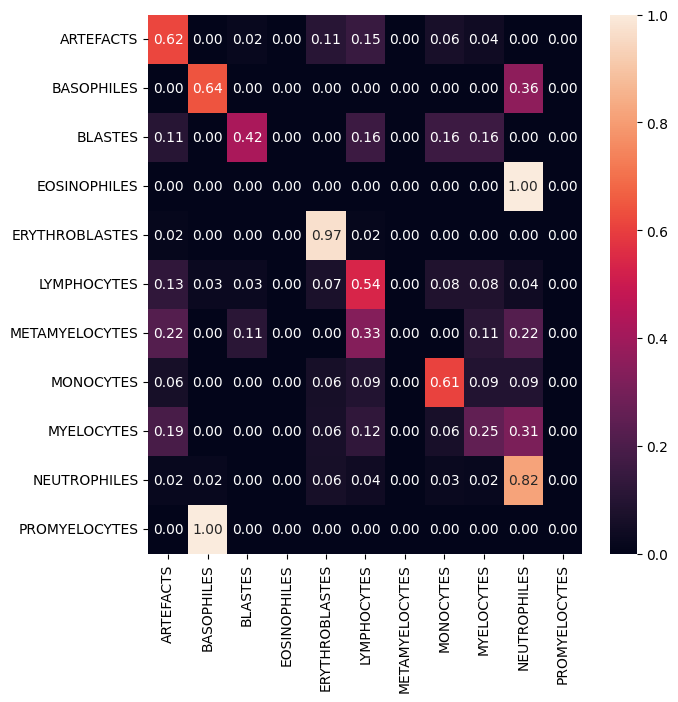

                precision    recall  f1-score   support

     ARTEFACTS       0.54      0.62      0.57        47
    BASOPHILES       0.60      0.64      0.62        14
       BLASTES       0.67      0.42      0.52        19
  EOSINOPHILES       0.00      0.00      0.00         1
ERYTHROBLASTES       0.92      0.97      0.94       265
   LYMPHOCYTES       0.58      0.54      0.55        71
METAMYELOCYTES       0.00      0.00      0.00         9
     MONOCYTES       0.54      0.61      0.57        33
    MYELOCYTES       0.18      0.25      0.21        16
  NEUTROPHILES       0.87      0.82      0.84       152
 PROMYELOCYTES       0.00      0.00      0.00         1

      accuracy                           0.78       628
     macro avg       0.44      0.44      0.44       628
  weighted avg       0.77      0.78      0.77       628



In [21]:
class_counts = train['label_encoded'].value_counts().sort_index()
sample_weights = train['label_encoded'].map(lambda x: 1.0 / class_counts[x]).values
sampler = WeightedRandomSampler(torch.DoubleTensor(sample_weights), len(sample_weights), replacement=True)

dataloader_train_balanced = torch.utils.data.DataLoader(
    train_dataset_resnet,
    batch_size=8,
    sampler=sampler
)

resnet_balanced = resnet50(weights=weights)
resnet_balanced.fc = nn.Linear(resnet_balanced.fc.in_features, len(classes))
resnet_balanced = resnet_balanced.to(device)

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_balanced.parameters(), lr=0.001, momentum=0.9)

train_model(resnet_balanced, 10, loss, optimizer, dataloader_train_balanced, dataloader_test_resnet)
predicted_test, label_test, accuracy = find_accuracy(resnet_balanced, dataloader_test_resnet)
plot_confusion(predicted_test, label_test)
print(classification_report(
    label_test,
    predicted_test,
    labels=list(range(len(classes))),
    target_names=classes,
    zero_division=0
))


Balanced sampling improves the training signal for underrepresented classes: they appear more often in the batches, so the model pays more attention to them instead of focusing mainly on the dominant labels.

In practice, this usually leads to a **better recall on rare classes** and a less concentrated confusion matrix. The trade-off is that the optimization becomes noisier and the global accuracy may stagnate or decrease slightly, because the model is no longer optimized primarily for the most frequent classes. So the result is often more balanced and more clinically interesting, even if the headline accuracy does not increase much.

13. Discuss about the overall results, compared with Machine Learning methods
used in the first TP.

Compared with the first TP, the deep learning approach has a major advantage: it works directly from the raw images and can learn complex visual patterns automatically, instead of relying only on handcrafted descriptors.

Overall, the pretrained CNN is more powerful than standard machine learning models when enough visual information is present, especially for the well-represented classes. However, the comparison also shows an important limitation: deep models are more data-hungry and remain very sensitive to class imbalance. In the first TP, classical methods may have been simpler and sometimes more stable on small structured features, whereas here the CNN can outperform them globally, but only if the data and the training strategy are adapted carefully.

# Go further

If you have made it this far, you can now think about more 'exotic' models that would perform better with this few data.



You can choose between these two options:

1. Try to create a siamese model. You can think of the best way to later evaluate the performance of your siamese network on this classification task.

2. Try to integrate features from the TP1 to your neural network, so that you add shape and colour information to the image. The neural network will thus have to handle in parallel table features and images.